# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">Import library</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from pandas_profiling import ProfileReport
import os
import joblib

C:\Users\acer\AppData\Local\Temp\ipykernel_21524\2413591960.py:9: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [2]:
os.makedirs(exist_ok = True,
            name     = "output/data/null/")

# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_ingestion</p>

## 1.1. Load data

In [3]:
DATA_DIR = "./data/"

df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_test = pd.read_csv(f"{DATA_DIR}/test.csv")
n_train = len(df_train)
print('Train Shape: ', df_train.shape)
print('Test Shape: ', df_test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


## 1.2. Peak data

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [6]:
print("train shape:", df_train.shape)
print("test shape:", df_test.shape)

train shape: (1460, 81)
test shape: (1459, 80)


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_validating</p>

## 2.1. Quick peak

In [7]:
train_profile = ProfileReport(df_train, title="Train Data")
test_profile  = ProfileReport(df_test, title="Test Data")

In [8]:
# display(train_profile)

In [9]:
# display(test_profile)

## 2.2. Check null

### 2.2.1. train

In [10]:
df_train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

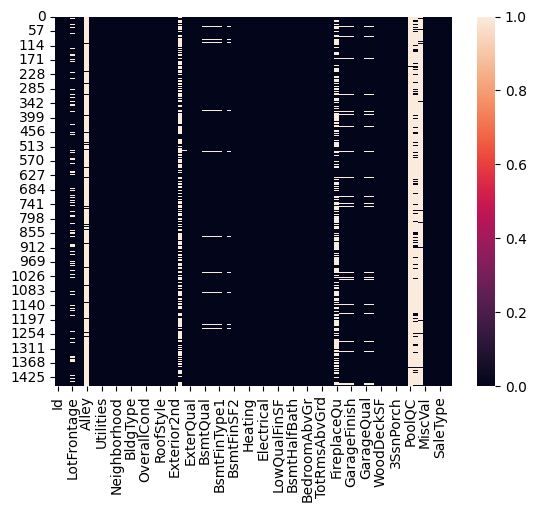

In [11]:
sns.heatmap(df_train.isnull())

plt.savefig(fname       = "output/data/null/before_train.png", 
            dpi         = 300, 
            bbox_inches ='tight')

### 2.2.2. test

In [12]:
df_test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

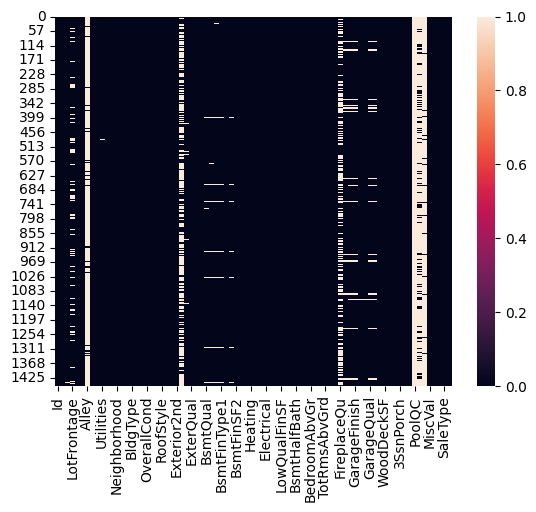

In [13]:
sns.heatmap(df_test.isnull())

plt.savefig(fname       = "output/data/null/before_test.png", 
            dpi         = 300, 
            bbox_inches ='tight')

## 2.3. Descriptive statistics

### 2.3.1. train

In [14]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### 2.3.2. test

In [15]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1459.0,2190.000000,421.321334,1461.0,1825.50,2190.0,2554.50,2919.0
MSSubClass,1459.0,57.378341,42.746880,20.0,20.00,50.0,70.00,190.0
LotFrontage,1232.0,68.580357,22.376841,21.0,58.00,67.0,80.00,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.00,9399.0,11517.50,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.00,6.0,7.00,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.00,5.0,6.00,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.00,1973.0,2001.00,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.00,1992.0,2004.00,2010.0
MasVnrArea,1444.0,100.709141,177.625900,0.0,0.00,0.0,164.00,1290.0
BsmtFinSF1,1458.0,439.203704,455.268042,0.0,0.00,350.5,753.50,4010.0


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_cleaning</p>

## 3.1. Handling null

### 3.1.1. train

replacing

In [16]:
cat_col_df_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'GarageQual', 'GarageCond']
ncat_col_df_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_df_train:
    df_train[i] = df_train[i].fillna(df_train[i].mode()[0])
for j in ncat_col_df_train:
    df_train[j] = df_train[j].fillna(df_train[j].mean())

dropping

In [17]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    df_train.drop([k], axis=1, inplace=True)

### 3.1.2. test

replacing

In [18]:
cat_col_df_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st',
                'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_df_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars',
                 'GarageArea']

for i in cat_col_df_test:
    df_test[i] = df_test[i].fillna(df_test[i].mode()[0])
for j in ncat_col_df_test:
    df_test[j] = df_test[j].fillna(df_test[j].mean())

dropping

In [19]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    df_test.drop([k], axis=1, inplace=True)

## 3.2. Checking data

### 3.2.1. train

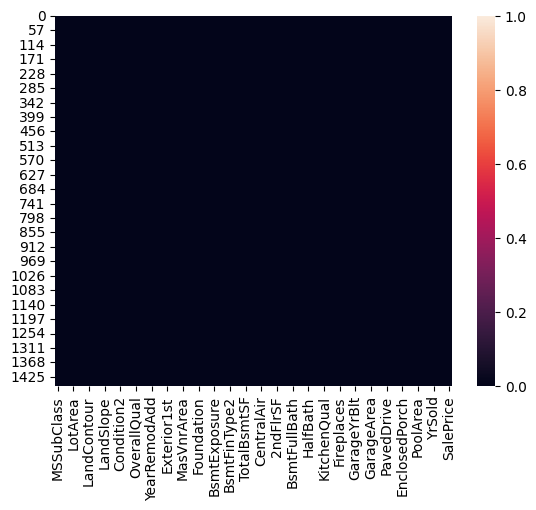

In [20]:
sns.heatmap(df_train.isnull())

plt.savefig(fname       = "output/data/null/after_train.png", 
            dpi         = 300, 
            bbox_inches ='tight')

### 3.2.1. test

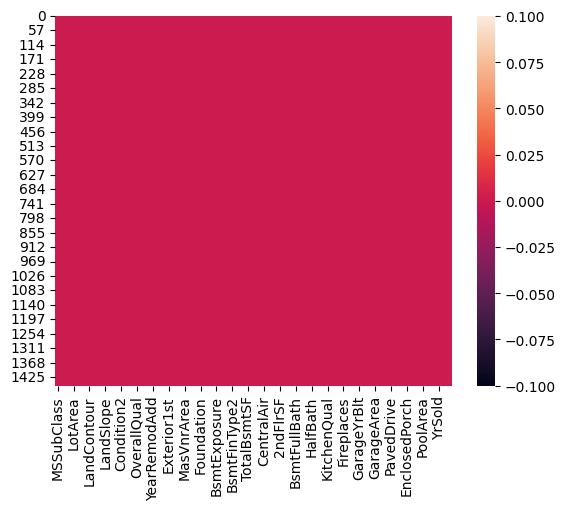

In [21]:
sns.heatmap(df_test.isnull())

plt.savefig(fname       = "output/data/null/after_test.png", 
            dpi         = 300, 
            bbox_inches ='tight')

## 3.3. Peak data

In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [23]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1459 non-null   object 
 2   LotFrontage    1459 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   LotShape       1459 non-null   object 
 6   LandContour    1459 non-null   object 
 7   Utilities      1459 non-null   object 
 8   LotConfig      1459 non-null   object 
 9   LandSlope      1459 non-null   object 
 10  Neighborhood   1459 non-null   object 
 11  Condition1     1459 non-null   object 
 12  Condition2     1459 non-null   object 
 13  BldgType       1459 non-null   object 
 14  HouseStyle     1459 non-null   object 
 15  OverallQual    1459 non-null   int64  
 16  OverallCond    1459 non-null   int64  
 17  YearBuilt      1459 non-null   int64  
 18  YearRemo

In [24]:
print("train shape:", df_train.shape)
print("test shape:", df_test.shape)

train shape: (1460, 76)
test shape: (1459, 75)


## 3.4. Descriptive statistics

### 3.4.1. train

In [25]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.000000,70.00,190.0
LotFrontage,1460.0,70.049958,22.024023,21.0,60.00,70.049958,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.500000,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.000000,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.000000,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.000000,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.000000,2004.00,2010.0
MasVnrArea,1460.0,103.685262,180.569112,0.0,0.00,0.000000,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.500000,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.000000,0.00,1474.0


### 3.4.2. test

In [26]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1459.0,57.378341,42.746880,20.0,20.0,50.000000,70.0,190.0
LotFrontage,1459.0,68.580357,20.561228,21.0,60.0,68.580357,78.0,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.0,9399.000000,11517.5,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.0,6.000000,7.0,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.0,5.000000,6.0,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.0,1973.000000,2001.0,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.0,1992.000000,2004.0,2010.0
MasVnrArea,1459.0,100.709141,176.709824,0.0,0.0,0.000000,162.0,1290.0
BsmtFinSF1,1459.0,439.203704,455.111888,0.0,0.0,351.000000,752.0,4010.0
BsmtFinSF2,1459.0,52.619342,176.693301,0.0,0.0,0.000000,0.0,1526.0


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_serving</p>

## 4.1. for data_analyst

## 4.2. for model_training

### 4.2.1. Indicate feature/target

In [27]:
feature = [x for x in df_train.columns if x not in ['Id', 'SalePrice']]
target  = 'SalePrice'

### 4.2.2. Splitting data

In [28]:
x_train = df_train[feature]
y_train = df_train[target]
x_test  = df_test[feature]

In [29]:
X_tr, X_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [30]:
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr shape:", y_tr.shape)
print("y_val shape:", y_val.shape)

X_tr shape: (1168, 75)
X_val shape: (292, 75)
y_tr shape: (1168,)
y_val shape: (292,)


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_transformation</p>

In [31]:
numerical_feature   = [x for x in X_tr.select_dtypes(include=['int64', 'float64']).columns]
categorical_feature = [x for x in X_tr.select_dtypes(include=['object']).columns]

## 5.1. Min-max numerical feature

In [32]:
mms = MinMaxScaler(feature_range=(0, 1))
mms.fit(X_tr[numerical_feature])

MinMaxScaler()

In [33]:
X_tr[numerical_feature]   = mms.transform(X_tr[numerical_feature])
X_val[numerical_feature]  = mms.transform(X_val[numerical_feature])
x_test[numerical_feature] = mms.transform(x_test[numerical_feature])

In [34]:
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", x_test.shape)

X_tr shape: (1168, 75)
X_val shape: (292, 75)
X_test shape: (1459, 75)


## 5.2. One-hot categorical feature

In [35]:
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(X_tr[categorical_feature])

OneHotEncoder(handle_unknown='ignore')

In [36]:
temp_train    = X_tr[categorical_feature]
train_encoded = pd.DataFrame(data = ohe.transform(temp_train).toarray(),
                             columns = ohe.get_feature_names_out(categorical_feature),
                             index = X_tr.index)
X_tr          = X_tr.drop(categorical_feature, axis=1)
X_tr          = pd.concat([X_tr, train_encoded], axis=1)


temp_val    = X_val[categorical_feature]
val_encoded = pd.DataFrame(data = ohe.transform(temp_val).toarray(),
                           columns = ohe.get_feature_names_out(categorical_feature),
                           index = X_val.index)
X_val       = X_val.drop(categorical_feature, axis=1)
X_val       = pd.concat([X_val, val_encoded], axis=1)


temp_test    = x_test[categorical_feature]
test_encoded = pd.DataFrame(data    = ohe.transform(temp_test).toarray(),
                            columns = ohe.get_feature_names_out(categorical_feature),
                            index   = x_test.index)
X_test       = x_test.drop(categorical_feature, axis=1)
X_test       = pd.concat([X_test, test_encoded], axis=1)

In [37]:
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_tr shape: (1168, 273)
X_val shape: (292, 273)
X_test shape: (1459, 273)


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_saving</p>

## 8.1. Save cleaned_data

In [38]:
cleaned_dirs = "data/cleaned"
os.makedirs(exist_ok = True,
            name     = cleaned_dirs)

df_train.to_csv(path_or_buf = f"{cleaned_dirs}/train.csv",
                index       = False)
df_test.to_csv(path_or_buf = f"{cleaned_dirs}/test.csv",
               index       = False)

## 8.2. Save processed_data

In [39]:
df_model = {}
df_model["train"] = pd.concat([X_tr, y_tr], axis=1)
df_model["valid"] = pd.concat([X_val, y_val], axis=1)
df_model["test"]  = X_test

In [40]:
processed_dirs = "data/processed"
os.makedirs(exist_ok = True,
            name     = processed_dirs)

df_model["train"].to_csv(path_or_buf = f"{processed_dirs}/train.csv",
                         index       = False)
df_model["valid"].to_csv(path_or_buf = f"{processed_dirs}/valid.csv",
                         index       = False)
df_model["test"].to_csv(path_or_buf = f"{processed_dirs}/test.csv",
                        index       = False)

## 8.3. Save scaler

In [41]:
os.makedirs(exist_ok = True,
            name     = "model")

In [42]:
joblib.dump(value    = mms,
            filename = "model/mms.pkl")
joblib.dump(value    = mms,
            filename = "model/ohe.pkl")

['model/ohe.pkl']